# aFRR Activation Price Metric Comparison (Germany, PICASSO)

## Economic Motivation
For BESS profit optimization in the German aFRR market under PICASSO (pay-as-cleared context),
the selected activation price metric directly controls expected upside in scarcity periods.

This notebook compares five POS-side price metrics:
1. `afrr_marginal_activation_price_pos` (official marginal; known ±15,000 placeholder issue)
2. `afrr_avg_activation_price_pos` (official average)
3. `afrr_activation_price_vwap_pos` (pipeline VWAP from 15-min price × activated volume)
4. `afrr_bid_vwap_activation_price_pos` (reconstructed bid VWAP)
5. `afrr_bid_avg_activation_price_pos` (engineered marginal proxy from bid extremes)

Goal: demonstrate why a specific metric is economically preferable for BESS profit modeling.


In [38]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (14, 6)

# Unified project plotting style
try:
    from energy_trading.visualization.style import apply_geo_style
except ModuleNotFoundError:
    import sys
    from pathlib import Path

    _root = Path.cwd().resolve()
    if _root.name == 'notebooks':
        _root = _root.parent
    _src = _root / 'src'
    if str(_src) not in sys.path:
        sys.path.insert(0, str(_src))
    from energy_trading.visualization.style import apply_geo_style

apply_geo_style()


## Input Assumption
A Polars DataFrame `df` with `timestamp_utc` is available in memory.

If not, uncomment the fallback loader.

In [39]:
# Robust input loading: find processed parquet from project root regardless of notebook cwd.
rel_candidates = [
    Path("data/processed/cleaned_data.parquet"),
    Path("data/processed/all_data_clean.parquet"),
    Path("data/processed/all_data_refined.parquet"),
    Path("data/processed/all_data.parquet"),
]
search_roots = [Path.cwd(), *Path.cwd().parents]
DATA_PATH = None
for root in search_roots:
    for rel in rel_candidates:
        candidate = (root / rel).resolve()
        if candidate.exists():
            DATA_PATH = candidate
            break
    if DATA_PATH is not None:
        break

if DATA_PATH is None:
    tried = "\n".join(str((r / rel).resolve()) for r in search_roots for rel in rel_candidates)
    raise FileNotFoundError("No processed parquet found. Tried:\n" + tried)

print("Loaded:", DATA_PATH)
df = pl.read_parquet(DATA_PATH)

if "df" not in globals():
    raise ValueError("Expected a Polars DataFrame named `df` in notebook scope.")
if not isinstance(df, pl.DataFrame):
    raise TypeError("`df` must be a Polars DataFrame.")


## Analysis Class
Object-oriented helper for validation, preprocessing, and plotting.

In [40]:
class AFRRPriceMetricAnalyzer:
    def __init__(self, df_pl: pl.DataFrame):
        self.df_pl = df_pl

        # Canonical metric names with fallback candidates.
        self.metric_candidates = {
            "afrr_marginal_activation_price_pos": [
                "afrr_marginal_activation_price_pos",
                "afrr_activation_marginal_price_pos",
            ],
            "afrr_avg_activation_price_pos": [
                "afrr_avg_activation_price_pos",
                "afrr_activation_avg_price_pos",
            ],
            "afrr_activation_price_vwap_pos": [
                "afrr_activation_price_vwap_pos",
            ],
            "afrr_bid_vwap_activation_price_pos": [
                "afrr_bid_vwap_activation_price_pos",
                "bid_signed_vwap_eur_mwh_pos",
            ],
            "afrr_bid_avg_activation_price_pos": [
                "afrr_bid_avg_activation_price_pos",
                "afrr_reconstructed_marginal_price_pos",
            ],
        }

        self.colmap = self._resolve_columns()
        self._validate_timestamp()
        self.df_pd = self._prepare_pd()

    def _first_existing(self, candidates: list[str]) -> str | None:
        for c in candidates:
            if c in self.df_pl.columns:
                return c
        return None

    def _resolve_columns(self) -> dict[str, str | None]:
        return {k: self._first_existing(v) for k, v in self.metric_candidates.items()}

    def _validate_timestamp(self) -> None:
        if "timestamp_utc" not in self.df_pl.columns:
            raise ValueError("Missing required column: timestamp_utc")

    def _prepare_pd(self) -> pd.DataFrame:
        select_cols = ["timestamp_utc"] + [c for c in self.colmap.values() if c is not None]
        d = (
            self.df_pl
            .select(select_cols)
            .with_columns(
                pl.col("timestamp_utc").cast(pl.Datetime(time_zone="UTC"), strict=False),
                *[
                    pl.col(c).cast(pl.Float64, strict=False)
                    for c in select_cols
                    if c != "timestamp_utc"
                ],
            )
            .drop_nulls(subset=["timestamp_utc"])
            .sort("timestamp_utc")
            .to_pandas()
        )

        # Rename resolved source columns to canonical names.
        rename_map = {
            src: canon
            for canon, src in self.colmap.items()
            if src is not None and src != canon and src in d.columns
        }
        if rename_map:
            d = d.rename(columns=rename_map)

        d["timestamp_utc"] = pd.to_datetime(d["timestamp_utc"], utc=True)
        d = d.set_index("timestamp_utc").sort_index()
        return d

    def print_column_status(self) -> None:
        print("Column availability (canonical -> resolved):")
        for canon, src in self.colmap.items():
            print(f"  {canon}: {src}")
        missing = [k for k, v in self.colmap.items() if v is None]
        if missing:
            print("\nMissing metrics:", missing)
            print(
                "Hint: bid-based columns are missing when regelleistung was collected with "
                "--skip-bid-activation-prices."
            )

    @staticmethod
    def remove_15000_placeholders(d: pd.DataFrame) -> pd.DataFrame:
        if "afrr_marginal_activation_price_pos" not in d.columns:
            return d.copy()
        mask = d["afrr_marginal_activation_price_pos"].abs() < 14999
        return d.loc[mask].copy()

    @staticmethod
    def select_high_volatility_window(
        d: pd.DataFrame,
        target_col: str = "afrr_bid_avg_activation_price_pos",
        hours: int = 24 * 7,
    ) -> tuple[pd.Timestamp, pd.Timestamp]:
        if target_col not in d.columns:
            target_col = "afrr_activation_price_vwap_pos" if "afrr_activation_price_vwap_pos" in d.columns else d.columns[0]
        s = d[target_col].dropna()
        if len(s) < hours:
            return d.index.min(), d.index.max()

        rolling_std = s.rolling(window=hours, min_periods=max(24, hours // 3)).std()
        end = rolling_std.idxmax()
        start = end - pd.Timedelta(hours=hours - 1)
        return start, end

    def _available_metric_cols(self) -> list[str]:
        return [c for c in self.metric_candidates.keys() if c in self.df_pd.columns]

    def plot_section1_corrupted_baseline(self) -> None:
        if "afrr_marginal_activation_price_pos" not in self.df_pd.columns:
            raise ValueError("Section 1 requires afrr_marginal_activation_price_pos")
        d = self.df_pd
        fig, ax = plt.subplots(figsize=(16, 5))
        ax.plot(d.index, d["afrr_marginal_activation_price_pos"], color="#B22222", lw=0.8)
        ax.axhline(15000, color="black", ls="--", lw=1, alpha=0.6)
        ax.axhline(-15000, color="black", ls="--", lw=1, alpha=0.6)
        ax.set_title("Section 1: Corrupted Baseline – Official Marginal Price (POS)")
        ax.set_xlabel("Timestamp (UTC)")
        ax.set_ylabel("EUR/MWh")
        plt.tight_layout()
        plt.show()

    def plot_section2_timeseries(self) -> tuple[pd.Timestamp, pd.Timestamp]:
        d = self.remove_15000_placeholders(self.df_pd)

        if "afrr_activation_price_vwap_pos" not in d.columns:
            raise ValueError("Section 2 requires afrr_activation_price_vwap_pos")

        target_col = (
            "afrr_bid_avg_activation_price_pos"
            if "afrr_bid_avg_activation_price_pos" in d.columns
            else "afrr_avg_activation_price_pos"
        )
        if target_col != "afrr_bid_avg_activation_price_pos":
            print("Note: afrr_bid_avg_activation_price_pos not available, using afrr_avg_activation_price_pos as fallback.")

        start, end = self.select_high_volatility_window(d, target_col=target_col)
        w = d.loc[start:end]

        fig, ax = plt.subplots(figsize=(16, 6))
        ax.plot(w.index, w["afrr_activation_price_vwap_pos"], label="afrr_activation_price_vwap_pos (system-average proxy)", lw=1.8)
        ax.plot(
            w.index,
            w[target_col],
            label=f"{target_col} (marginal-like comparator)",
            lw=1.4,
        )
        ax.set_title("Section 2: High-Volatility Window – VWAP vs Marginal Comparator (POS)")
        ax.set_xlabel("Timestamp (UTC)")
        ax.set_ylabel("EUR/MWh")
        ax.legend()
        plt.tight_layout()
        plt.show()

        return start, end

    def plot_section3_correlation(self) -> pd.DataFrame:
        d = self.remove_15000_placeholders(self.df_pd)
        cols = self._available_metric_cols()
        if len(cols) < 2:
            raise ValueError("Section 3 requires at least two available metric columns.")
        corr = d[cols].corr(method="pearson")

        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(
            corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            ax=ax,
        )
        ax.set_title("Section 3: Pearson Correlation Matrix (POS, placeholders removed)")
        plt.tight_layout()
        plt.show()

        return corr

    def plot_section4_distributions(self, clip_abs: float = 3000.0) -> None:
        d = self.remove_15000_placeholders(self.df_pd)
        cols = self._available_metric_cols()
        if not cols:
            raise ValueError("Section 4 requires at least one available metric column.")

        long_df = (
            d[cols]
            .reset_index()
            .melt(id_vars="timestamp_utc", var_name="metric", value_name="price_eur_mwh")
        )
        long_df = long_df[np.isfinite(long_df["price_eur_mwh"])]
        long_df = long_df[long_df["price_eur_mwh"].abs() <= clip_abs]

        fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

        sns.boxplot(data=long_df, x="metric", y="price_eur_mwh", showfliers=False, ax=axes[0])
        axes[0].set_title(f"Section 4A: Boxplot (|price| <= {clip_abs:.0f})")
        axes[0].tick_params(axis="x", rotation=30)
        axes[0].set_xlabel("")
        axes[0].set_ylabel("EUR/MWh")

        sns.violinplot(data=long_df, x="metric", y="price_eur_mwh", cut=0, inner="quartile", ax=axes[1])
        axes[1].set_title(f"Section 4B: Violin Plot (|price| <= {clip_abs:.0f})")
        axes[1].tick_params(axis="x", rotation=30)
        axes[1].set_xlabel("")
        axes[1].set_ylabel("")

        plt.tight_layout()
        plt.show()


## Section 1: Corrupted Baseline (Official Marginal)
Visual evidence of extreme ±15,000 EUR/MWh outliers, making the raw official marginal
series unsuitable as direct ML target without robust cleaning.

Column availability (canonical -> resolved):
  afrr_marginal_activation_price_pos: afrr_marginal_activation_price_pos
  afrr_avg_activation_price_pos: afrr_avg_activation_price_pos
  afrr_activation_price_vwap_pos: afrr_activation_price_vwap_pos
  afrr_bid_vwap_activation_price_pos: afrr_bid_vwap_activation_price_pos
  afrr_bid_avg_activation_price_pos: afrr_bid_avg_activation_price_pos


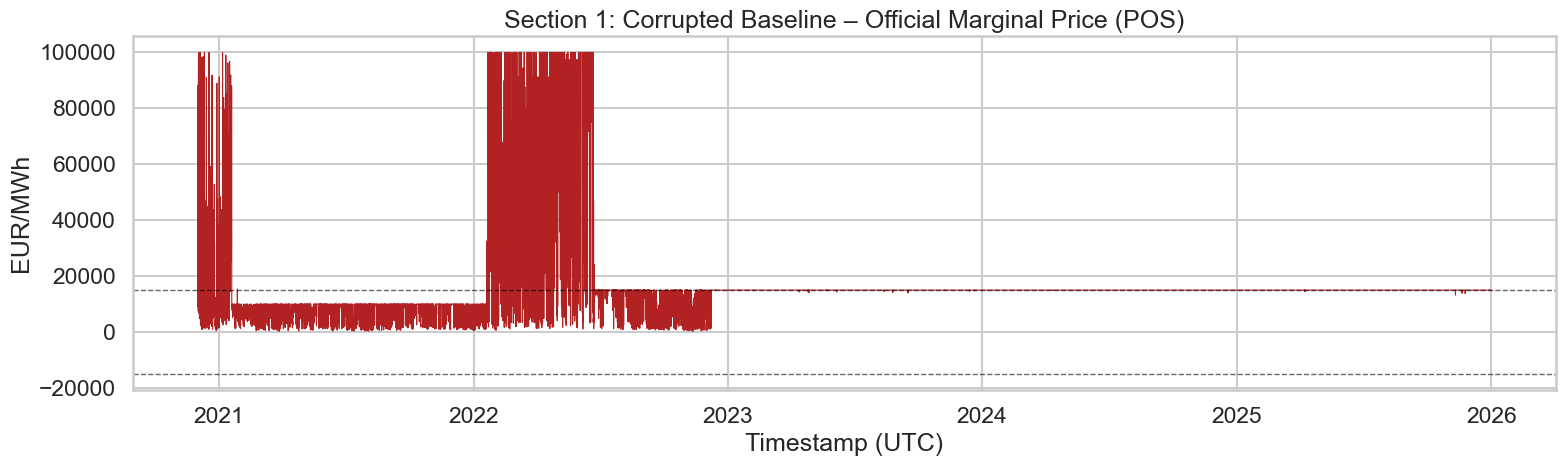

In [41]:
analyzer = AFRRPriceMetricAnalyzer(df)
analyzer.print_column_status()
analyzer.plot_section1_corrupted_baseline()

## Section 2: Time-Series Comparison (Marginal Proxy vs VWAP)
In pay-as-cleared economics, marginal-price-like signals should preserve scarcity spikes.
This section compares the smoothed VWAP against the engineered marginal proxy in a high-volatility week.

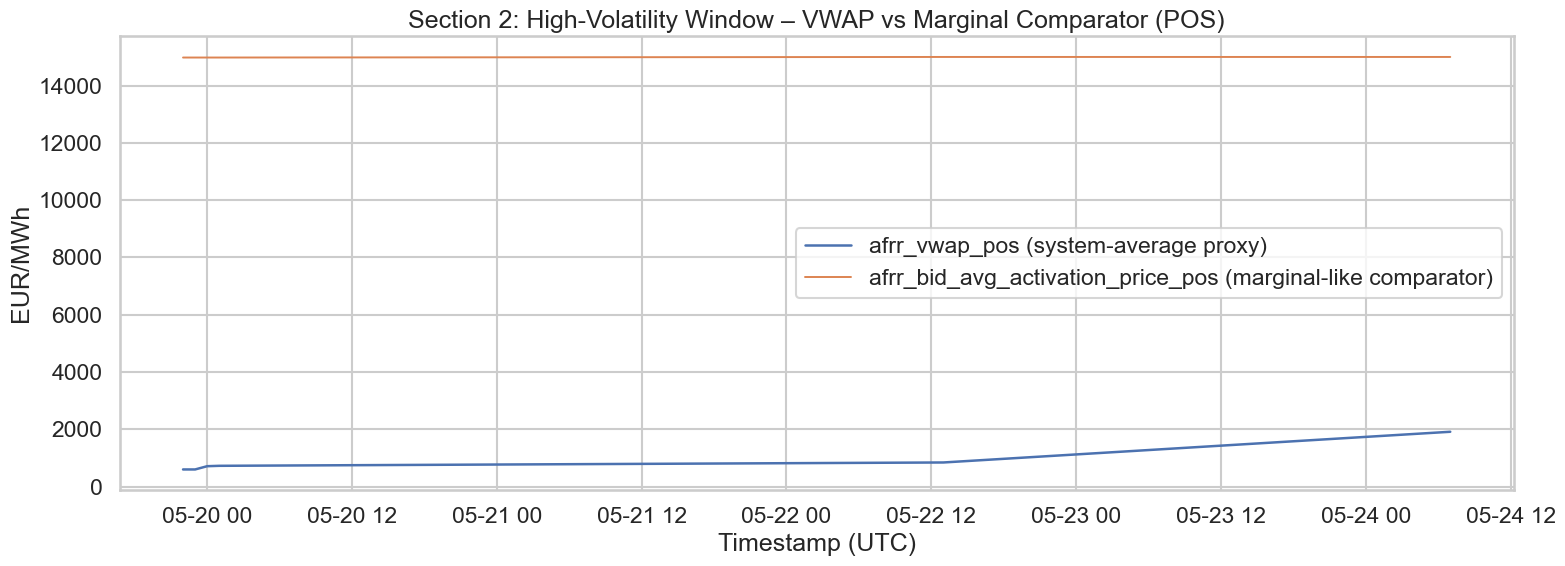

Selected high-volatility window: 2023-05-17 08:00:00+00:00 -> 2023-05-24 07:00:00+00:00


In [42]:
start_ts, end_ts = analyzer.plot_section2_timeseries()
print(f"Selected high-volatility window: {start_ts} -> {end_ts}")


## Section 3: Pipeline Validation (Correlation Matrix)
After removing ±15,000 placeholder artifacts, strong correlation between average/VWAP variants
supports internal pipeline consistency, while a marginal proxy should remain structurally distinct.

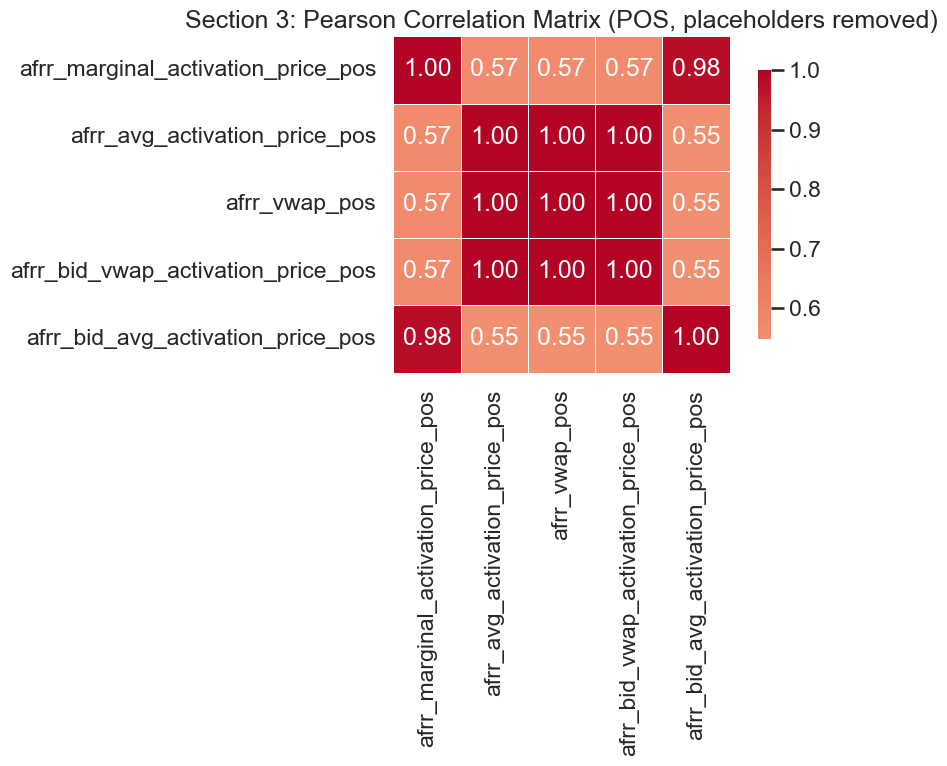

,afrr_marginal_activation_price_pos,afrr_avg_activation_price_pos,afrr_activation_price_vwap_pos,afrr_bid_vwap_activation_price_pos,afrr_bid_avg_activation_price_pos
afrr_marginal_activation_price_pos,1.000000,0.567324,0.567269,0.567269,0.978128
afrr_avg_activation_price_pos,0.567324,1.000000,0.999997,0.999997,0.548823
afrr_activation_price_vwap_pos,0.567269,0.999997,1.000000,1.000000,0.548732
afrr_bid_vwap_activation_price_pos,0.567269,0.999997,1.000000,1.000000,0.548732
afrr_bid_avg_activation_price_pos,0.978128,0.548823,0.548732,0.548732,1.000000


In [43]:
corr = analyzer.plot_section3_correlation()
corr


## Section 4: Distribution Comparison (Box/Violin)
Distributional spread highlights economic differences between average-like and marginal-like metrics.
For readability, extreme values above |3000| EUR/MWh are hidden in this view.

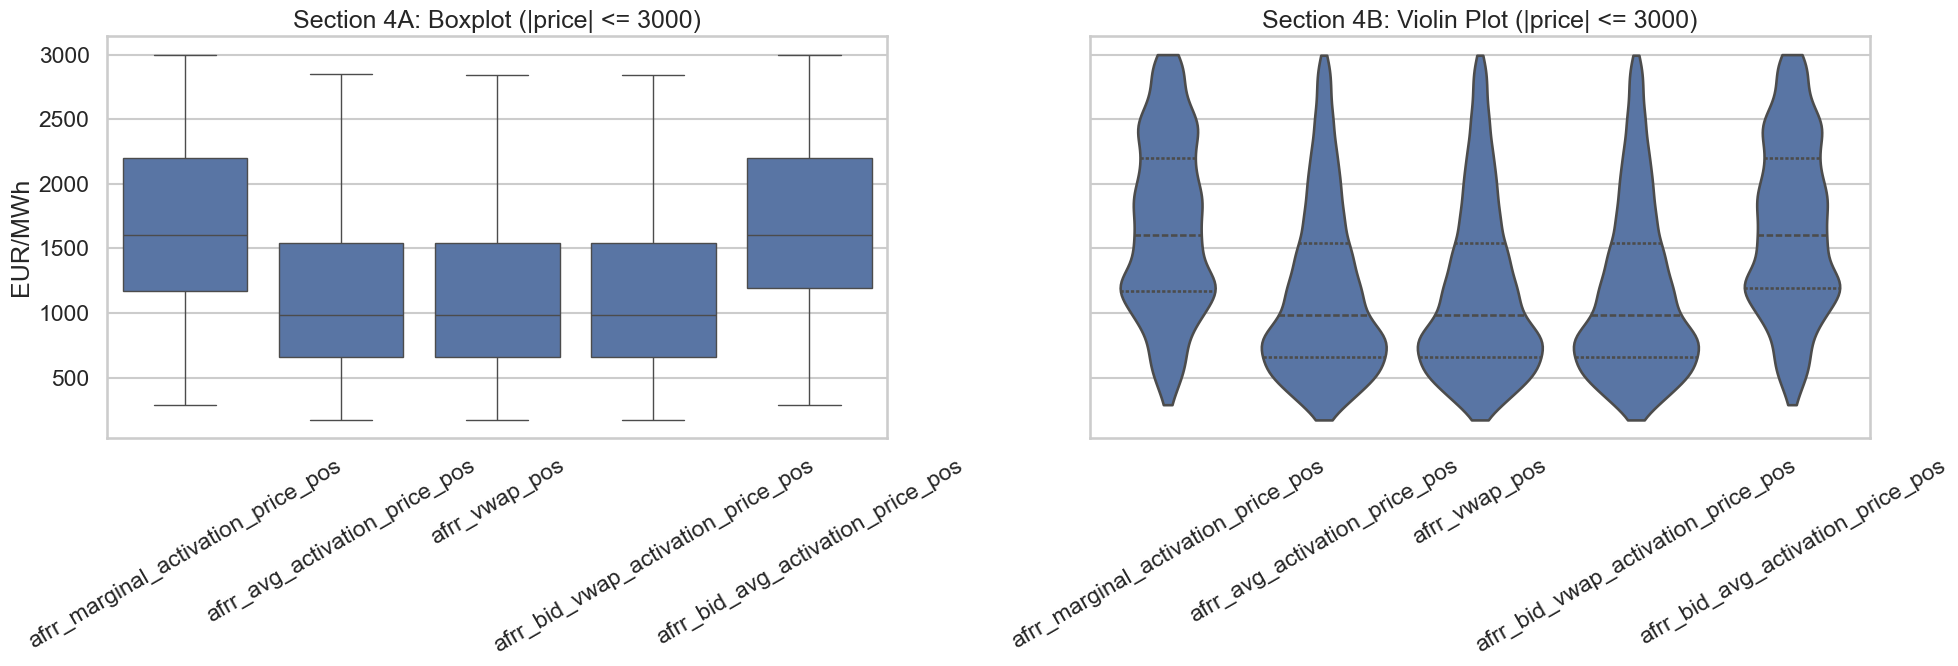

In [44]:
analyzer.plot_section4_distributions(clip_abs=3000.0)


## Interpretation Guide for Thesis
- If `afrr_activation_price_vwap_pos` is consistently smoother than `afrr_bid_avg_activation_price_pos`,
  it likely understates scarcity upside for BESS strategies.
- If `afrr_avg_activation_price_pos`, `afrr_activation_price_vwap_pos`, and `afrr_bid_vwap_activation_price_pos`
  show high correlation, your VWAP engineering is internally coherent.
- A structurally wider tail in `afrr_bid_avg_activation_price_pos` supports using a marginal-like
  proxy when profit capture in spikes is central to the objective.
